In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from tqdm import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

In [11]:
# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


In [12]:
# Define constants
IMAGE_SIZE = 256
BATCH_SIZE = 32
EPOCHS = 50
NUM_CLASSES = 6

In [13]:
# Classes for the model
classes = ['algal_spot', 'brown_blight', 'gray_blight', 'healthy', 'helopeltis', 'red_spot']

In [14]:
data_dir = "D:/Agro_model/training/model01/Tea_Leaf_Disease" 

In [15]:
# Create data generators for memory-efficient training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2,  # 20% for validation
    fill_mode='nearest'
)


In [16]:
# Flow from directory for training set
train_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    subset='training',
    shuffle=True
)

Found 4800 images belonging to 6 classes.


In [17]:
# Flow from directory for validation set
validation_generator = train_datagen.flow_from_directory(
    data_dir,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=classes,
    subset='validation',
    shuffle=False
)

Found 1200 images belonging to 6 classes.


In [19]:
# Creating the CNN model
def create_cnn_model():
    model = Sequential([
        # First Convolutional Block
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Second Convolutional Block
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Third Convolutional Block
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Flatten and Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    # Compile the model
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [20]:
# Create and display the model
model = create_cnn_model()
model.summary()


C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 256, 256, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256, 256, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 256, 256, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256, 256, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128, 128, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 128, 128, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 128, 128, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 128, 128, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 64, 64, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 64, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 67,403,302 (257.12 MB)

 Trainable params: 67,401,382 (257.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [21]:
# Set up callbacks
checkpoint = ModelCheckpoint(
    'tea_leaf_disease_model_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

callbacks = [checkpoint, early_stopping, reduce_lr]


In [22]:
# Train the model using generators
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks
)

C:\Users\User\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4148 - loss: 1.9392  
Epoch 1: val_accuracy improved from -inf to 0.18074, saving model to tea_leaf_disease_model_best.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.4151 - loss: 1.9372 - val_accuracy: 0.1807 - val_loss: 6.4516 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5415 - loss: 1.3181  
Epoch 2: val_accuracy did not improve from 0.18074
150/150 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.5416 - loss: 1.3178 - val_accuracy: 0.1571 - val_loss: 6.0011 - learning_rate: 0.0010
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5303 - loss: 1.2951  
Epoch 3: val_accuracy improved from 0.18074 to 0.40203, saving model to tea_leaf_disease_model_best.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 427s 3s/step - accuracy: 0.5303 - loss: 1.2949 - val_accuracy: 0.4020 - val_loss: 1.5001 - learning_rate: 0.0010
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5678 - loss: 1.1339  
Epoch 4: val_accuracy did not improve from 0.40203
150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.5679 - loss: 1.1336 - val_accuracy: 0.3843 - val_loss: 2.2235 - learning_rate: 0.0010
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6099 - loss: 0.9973  
Epoch 5: val_accuracy did not improve from 0.40203
150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.6100 - loss: 0.9970 - val_accuracy: 0.2466 - val_loss: 3.9838 - learning_rate: 0.0010
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6186 - loss: 0.9626  
Epoch 6: val_accuracy did not improve from 0.40203
150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.6187 - loss: 0.9624 - val_accuracy: 0.2340 - val_loss: 4.2655 - learning_rate: 0.0010
Epoch 7/50
150/150

150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.6825 - loss: 0.7963 - val_accuracy: 0.6934 - val_loss: 0.8271 - learning_rate: 0.0010
Epoch 8/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7028 - loss: 0.7558  
Epoch 8: val_accuracy did not improve from 0.69341
150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.7028 - loss: 0.7557 - val_accuracy: 0.5541 - val_loss: 1.3520 - learning_rate: 0.0010
Epoch 9/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7073 - loss: 0.7079  
Epoch 9: val_accuracy did not improve from 0.69341
150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.7074 - loss: 0.7078 - val_accuracy: 0.5549 - val_loss: 1.1822 - learning_rate: 0.0010
Epoch 10/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.7210 - loss: 0.6962  
Epoch 10: val_accuracy did not improve from 0.69341
150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.7210 - loss: 0.6962 - val_accuracy: 0.4096 - val_loss: 1.5853 - learning_rate: 0.0010
Epoch 11/50
150/

...

150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9343 - loss: 0.1942 - val_accuracy: 0.9105 - val_loss: 0.2756 - learning_rate: 2.0000e-04
Epoch 34/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9404 - loss: 0.1639  
Epoch 34: val_accuracy did not improve from 0.91047
150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9403 - loss: 0.1641 - val_accuracy: 0.9071 - val_loss: 0.2609 - learning_rate: 2.0000e-04
Epoch 35/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9307 - loss: 0.1939  
Epoch 35: val_accuracy did not improve from 0.91047

Epoch 35: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
150/150 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9308 - loss: 0.1939 - val_accuracy: 0.9105 - val_loss: 0.2775 - learning_rate: 2.0000e-04
Epoch 36/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9434 - loss: 0.1643  
Epoch 36: val_accuracy improved from 0.91047 to 0.93581, saving model to tea_leaf_disease_model_best.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.9434 - loss: 0.1643 - val_accuracy: 0.9358 - val_loss: 0.1759 - learning_rate: 4.0000e-05
Epoch 37/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9540 - loss: 0.1397  
Epoch 37: val_accuracy did not improve from 0.93581
150/150 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9540 - loss: 0.1397 - val_accuracy: 0.9341 - val_loss: 0.1770 - learning_rate: 4.0000e-05
Epoch 38/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9523 - loss: 0.1349  
Epoch 38: val_accuracy did not improve from 0.93581
150/150 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.9523 - loss: 0.1349 - val_accuracy: 0.9257 - val_loss: 0.1865 - learning_rate: 4.0000e-05
Epoch 39/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9607 - loss: 0.1161  
Epoch 39: val_accuracy did not improve from 0.93581
150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9607 - loss: 0.1161 - val_accuracy: 0.9316 - val_loss: 0.1883 - learning_rate: 4.0000e

150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9545 - loss: 0.1230 - val_accuracy: 0.9400 - val_loss: 0.1619 - learning_rate: 8.0000e-06
Epoch 43/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9544 - loss: 0.1194  
Epoch 43: val_accuracy did not improve from 0.94003
150/150 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.9544 - loss: 0.1194 - val_accuracy: 0.9350 - val_loss: 0.1740 - learning_rate: 8.0000e-06
Epoch 44/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9642 - loss: 0.1126  
Epoch 44: val_accuracy did not improve from 0.94003
150/150 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.9642 - loss: 0.1126 - val_accuracy: 0.9333 - val_loss: 0.1705 - learning_rate: 8.0000e-06
Epoch 45/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9574 - loss: 0.1234  
Epoch 45: val_accuracy improved from 0.94003 to 0.94257, saving model to tea_leaf_disease_model_best.h5


150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9574 - loss: 0.1234 - val_accuracy: 0.9426 - val_loss: 0.1609 - learning_rate: 8.0000e-06
Epoch 46/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9597 - loss: 0.1191  
Epoch 46: val_accuracy did not improve from 0.94257
150/150 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9597 - loss: 0.1191 - val_accuracy: 0.9392 - val_loss: 0.1648 - learning_rate: 8.0000e-06
Epoch 47/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9589 - loss: 0.1204  
Epoch 47: val_accuracy did not improve from 0.94257
150/150 ━━━━━━━━━━━━━━━━━━━━ 425s 3s/step - accuracy: 0.9589 - loss: 0.1204 - val_accuracy: 0.9383 - val_loss: 0.1741 - learning_rate: 8.0000e-06
Epoch 48/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9585 - loss: 0.1251  
Epoch 48: val_accuracy did not improve from 0.94257
150/150 ━━━━━━━━━━━━━━━━━━━━ 424s 3s/step - accuracy: 0.9585 - loss: 0.1251 - val_accuracy: 0.9426 - val_loss: 0.1547 - learning_rate: 8.0000e

150/150 ━━━━━━━━━━━━━━━━━━━━ 426s 3s/step - accuracy: 0.9643 - loss: 0.1152 - val_accuracy: 0.9434 - val_loss: 0.1593 - learning_rate: 8.0000e-06
Epoch 50/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9683 - loss: 0.1123  
Epoch 50: val_accuracy did not improve from 0.94341
150/150 ━━━━━━━━━━━━━━━━━━━━ 423s 3s/step - accuracy: 0.9683 - loss: 0.1123 - val_accuracy: 0.9341 - val_loss: 0.1781 - learning_rate: 8.0000e-06
Restoring model weights from the end of the best epoch: 48.


In [23]:
# Save the model
model.save('tea_leaf_disease_model_final.h5')

In [24]:
# Plot training history
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

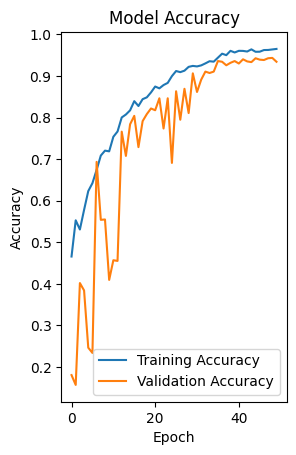

In [25]:
# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

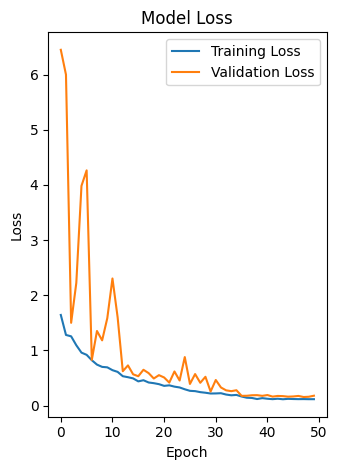

In [26]:
# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
# Evaluate the model on the validation set
validation_generator.reset()
Y_pred = model.predict(validation_generator, validation_generator.samples // BATCH_SIZE + 1)
y_pred = np.argmax(Y_pred, axis=1)

38/38 ━━━━━━━━━━━━━━━━━━━━ 17s 443ms/step


In [28]:
# Get true labels
validation_generator.reset()
y_true = validation_generator.classes[:len(y_pred)]

In [29]:
# Print classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=classes))


Classification Report:
              precision    recall  f1-score   support

  algal_spot       0.98      0.96      0.97       200
brown_blight       0.86      0.90      0.88       200
 gray_blight       0.94      0.89      0.92       200
     healthy       0.92      0.98      0.95       200
  helopeltis       0.97      0.93      0.95       200
    red_spot       0.95      0.95      0.95       200

    accuracy                           0.94      1200
   macro avg       0.94      0.94      0.94      1200
weighted avg       0.94      0.94      0.94      1200



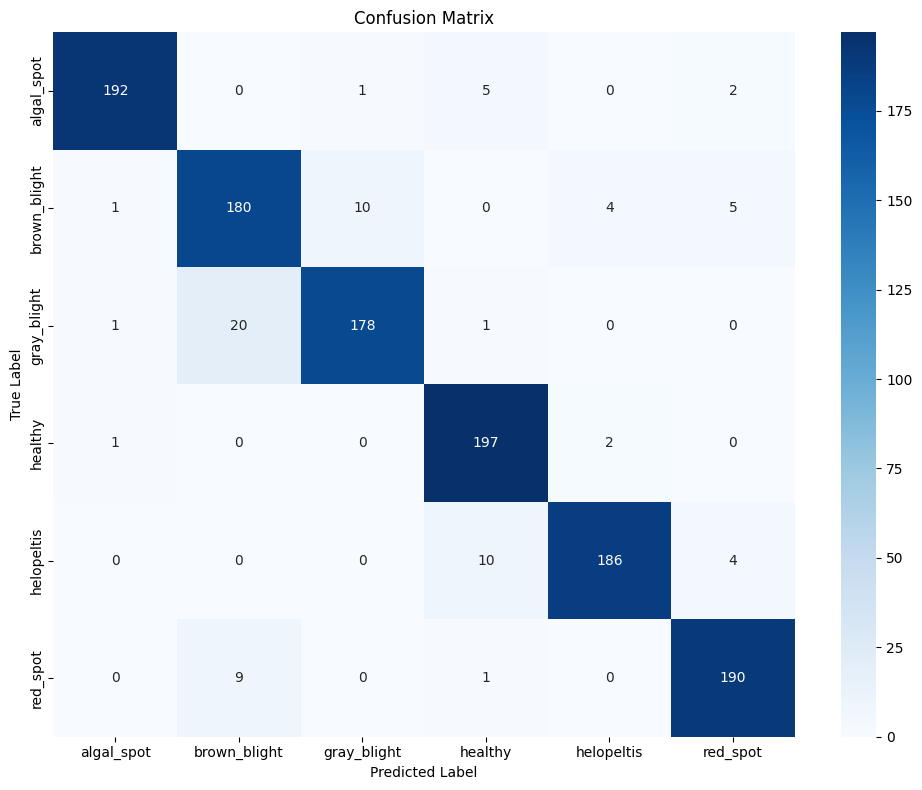

In [30]:
# Plot confusion matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

In [31]:
# Function to make predictions on new images
def predict_disease(img_path, model):
    from tensorflow.keras.preprocessing import image
    
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)
    confidence = np.max(prediction) * 100
    
    return classes[predicted_class], confidence

In [33]:
img_path = r"D:\Agro_model\training\model01\Tea_Leaf_Disease\red_spot\20211227_155702.jpg"

predicted_disease, confidence = predict_disease(img_path, model)

# Display the results
print(f"Predicted Disease: {predicted_disease}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
Predicted Disease: red_spot
Confidence: 100.00%


In [34]:
img_path = r"D:\Agro_model\training\model01\Tea_Leaf_Disease\brown_blight\20211205_155836.jpg"

predicted_disease, confidence = predict_disease(img_path, model)

# Display the results
print(f"Predicted Disease: {predicted_disease}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
Predicted Disease: brown_blight
Confidence: 99.82%


In [35]:
img_path = r"D:\Agro_model\training\model01\Tea_Leaf_Disease\gray_blight\20211227_163604.jpg"

predicted_disease, confidence = predict_disease(img_path, model)

# Display the results
print(f"Predicted Disease: {predicted_disease}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Disease: gray_blight
Confidence: 93.60%


In [39]:
img_path = r"D:\Agro_model\training\model01\Tea_Leaf_Disease\healthy\20220101_085808.jpg"

predicted_disease, confidence = predict_disease(img_path, model)

# Display the results
print(f"Predicted Disease: {predicted_disease}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Disease: healthy
Confidence: 99.98%


In [40]:
img_path = r"D:\Agro_model\training\PlantDisease\Brown_Blight\20211205_155637.jpg"

predicted_disease, confidence = predict_disease(img_path, model)

# Display the results
print(f"Predicted Disease: {predicted_disease}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
Predicted Disease: brown_blight
Confidence: 98.31%


In [41]:
def predict_disease_with_threshold(img_path, model, threshold=0.7):
    from tensorflow.keras.preprocessing import image
    import numpy as np
    
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Get prediction probabilities
    prediction = model.predict(img_array)[0]
    max_confidence = np.max(prediction)
    predicted_class = np.argmax(prediction)
    
    # Check if confidence is below threshold
    if max_confidence < threshold:
        return "Unknown (Not a tea leaf disease)", max_confidence * 100
    else:
        return classes[predicted_class], max_confidence * 100

In [42]:
# Path to your image
img_path = r"D:\Agro_model\training\PlantDisease\Brown_Blight\20211205_160617.jpg"

# Call the modified prediction function with a threshold
result, confidence = predict_disease_with_threshold(img_path, model, threshold=0.7)

# Display the results
print(f"Prediction: {result}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: brown_blight
Confidence: 99.89%


In [48]:
# Path to your image
img_path = r"C:\Users\User\Pictures\Download\dis.jpeg"

# Call the modified prediction function with a threshold
result, confidence = predict_disease_with_threshold(img_path, model, threshold=0.7)

# Display the results
print(f"Prediction: {result}")
print(f"Confidence: {confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction: gray_blight
Confidence: 100.00%


In [49]:
def visualize_prediction(img_path, model, threshold=0.7):
    import matplotlib.pyplot as plt
    from tensorflow.keras.preprocessing import image
    import numpy as np
    
    # Load image
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    
    # Get prediction
    prediction = model.predict(img_array)[0]
    max_conf = np.max(prediction)
    pred_class = np.argmax(prediction)
    
    # Determine result based on threshold
    if max_conf < threshold:
        result = "Unknown (Not a tea leaf disease)"
    else:
        result = classes[pred_class]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # Display image with prediction
    ax1.imshow(image.img_to_array(img)/255.0)
    ax1.set_title(f"Prediction: {result}\nConfidence: {max_conf*100:.2f}%")
    ax1.axis('off')
    
    # Display confidence bar chart
    bars = ax2.bar(classes, prediction * 100)
    bars[pred_class].set_color('green')
    ax2.axhline(y=threshold*100, color='r', linestyle='-', label=f'Threshold ({threshold*100}%)')
    ax2.set_ylim(0, 100)
    ax2.set_ylabel('Confidence (%)')
    ax2.set_title('Class Confidence Scores')
    ax2.set_xticklabels(classes, rotation=45, ha='right')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    return result, max_conf * 100

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


C:\Users\User\AppData\Local\Temp\ipykernel_11876\239666390.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(classes, rotation=45, ha='right')


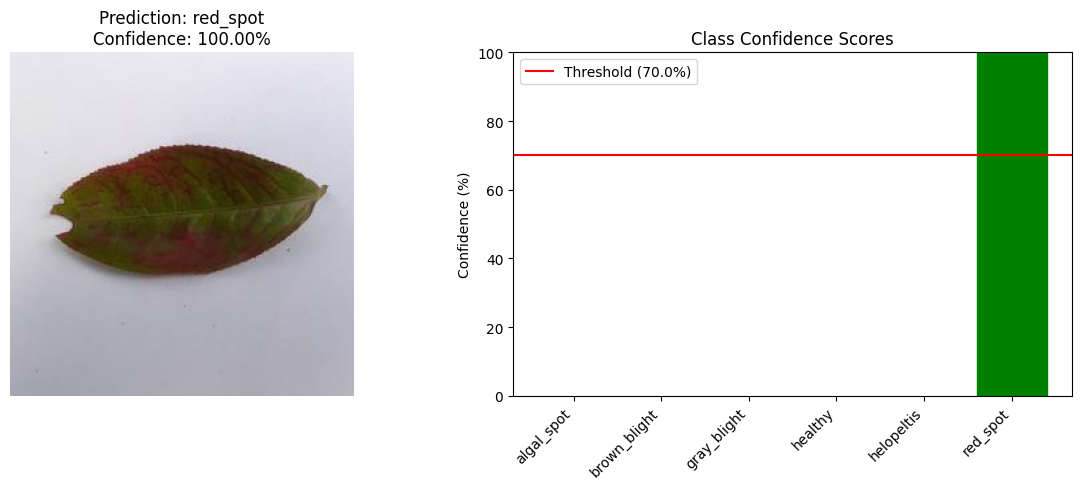

Prediction: red_spot
Confidence: 100.00%


In [50]:
img_path = r"D:\Agro_model\training\model01\Tea_Leaf_Disease\red_spot\20211227_155702.jpg"
result, confidence = visualize_prediction(img_path, model)
print(f"Prediction: {result}")
print(f"Confidence: {confidence:.2f}%")